In [113]:
from sklearn.preprocessing import StandardScaler 
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna() # load data from files

Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2415735.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2416143.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2415736.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy

In [174]:
df = pd.read_csv("updated_df.csv")

In [175]:
print(df.shape)

(2761, 19)


In [176]:
print(df.columns) # print the columns of the dataframe

Index(['QADate', 'Unit', 'Energy', 'MU', 'DPF', 'ADPass', 'RDPass', 'AD', 'RD',
       'D4DD', 'D4DTA', 'D4Gamma', 'Area', 'Circumference', 'MCS', 'Span',
       'CoA', 'MachineType', 'Mu_per_dpf'],
      dtype='object')


In [178]:
features = ['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS',"Mu_per_dpf"]

In [179]:
import seaborn as sns

In [181]:
df["QADate"] = pd.to_datetime(df["QADate"], errors="coerce")
print(df["QADate"].dt.year.unique())


[2024 2023]


In [92]:
df = df[df["AD"] != 0]


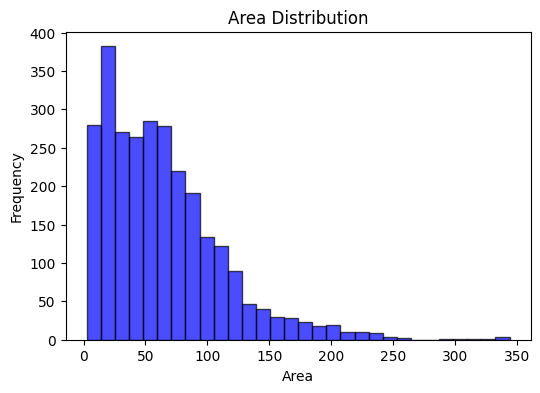

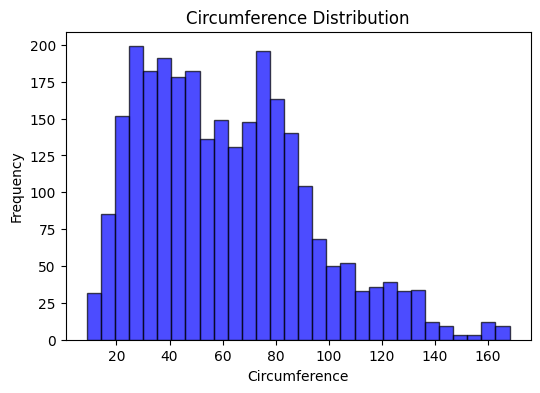

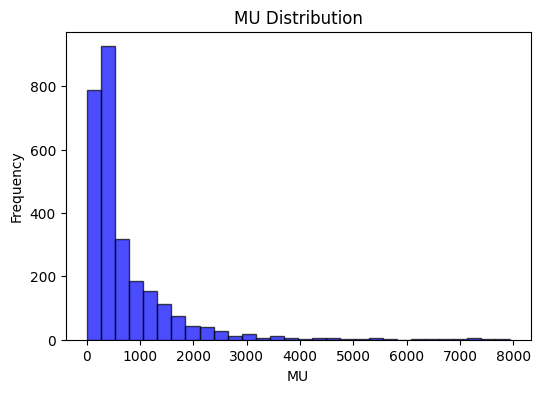

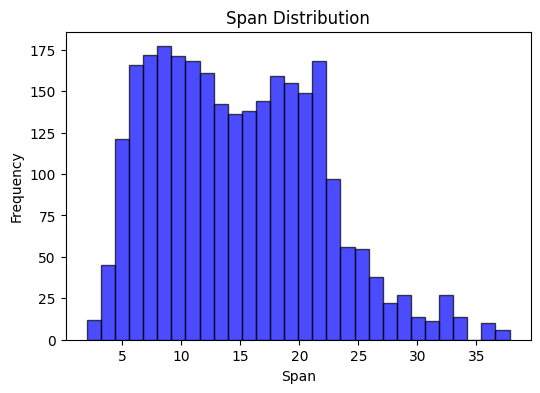

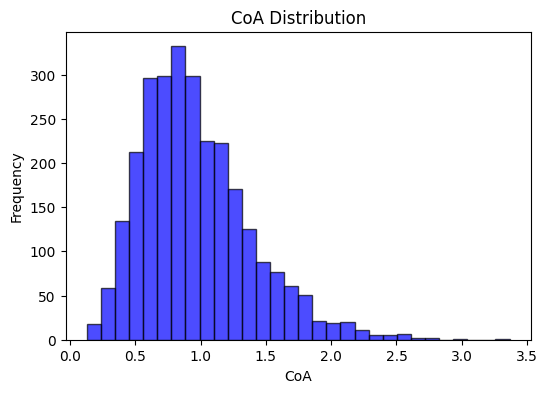

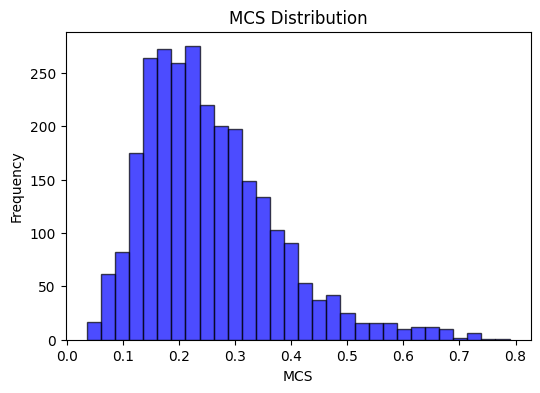

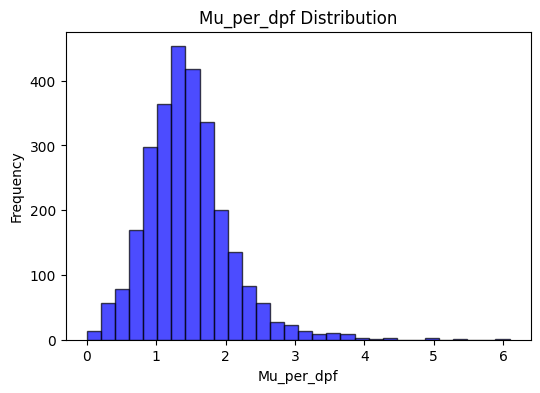

In [182]:
for f in features:
    plt.figure(figsize=(6,4))
    plt.hist(df[f],bins=30, color='blue', alpha=0.7, edgecolor='black')
    plt.title(f"{f} Distribution")
    plt.xlabel(f)
    plt.ylabel("Frequency")
    plt.show()




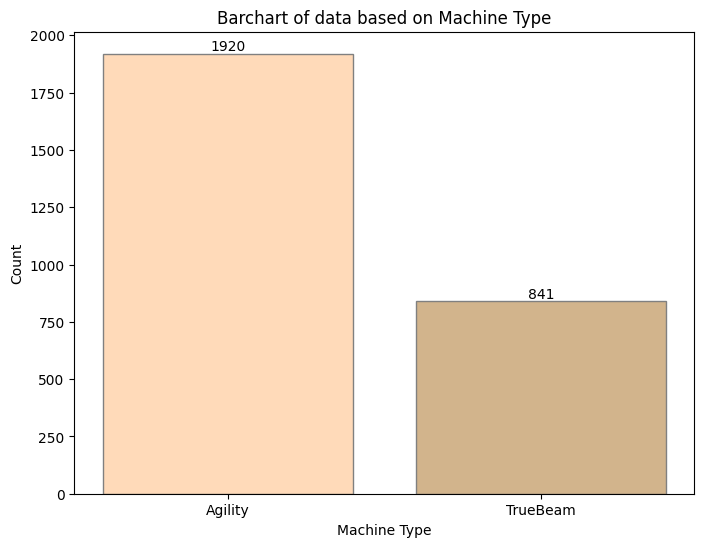

In [204]:
plt.figure(figsize=(8, 6))

bars = plt.bar(df['MachineType'].value_counts().index, df['MachineType'].value_counts().values,color=['peachpuff', 'tan'],edgecolor='grey')
plt.title("Barchart of data based on Machine Type")
plt.xlabel("Machine Type")
plt.ylabel("Count")
plt.bar_label(bars)
plt.show()

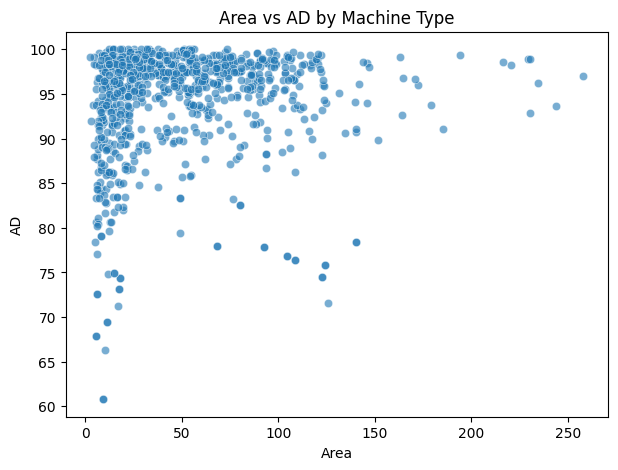

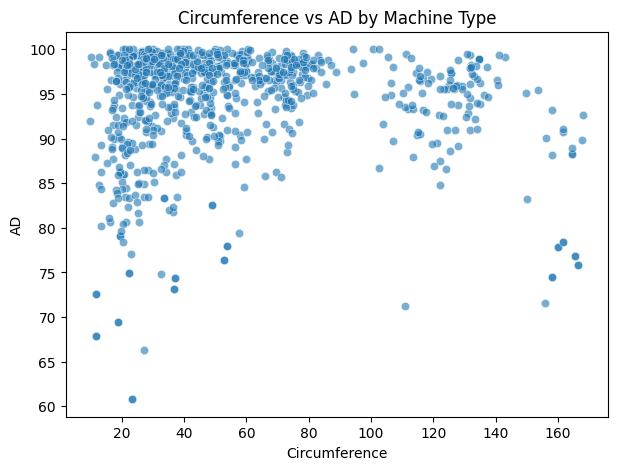

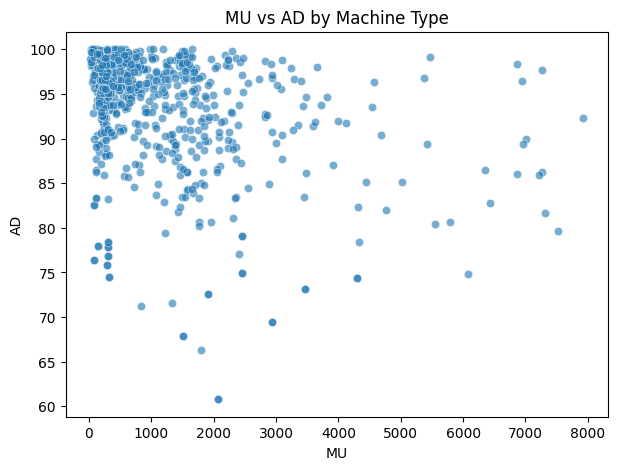

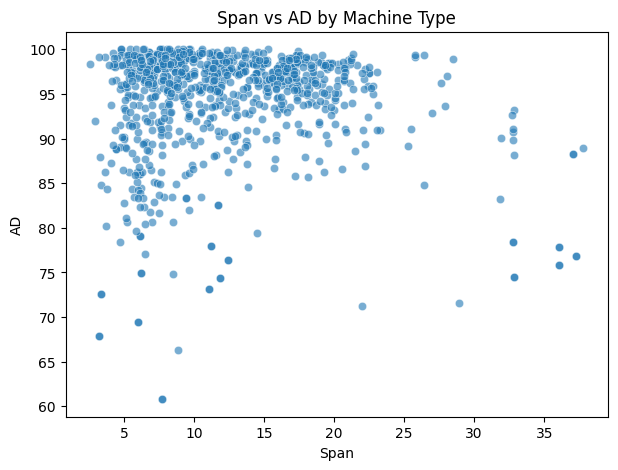

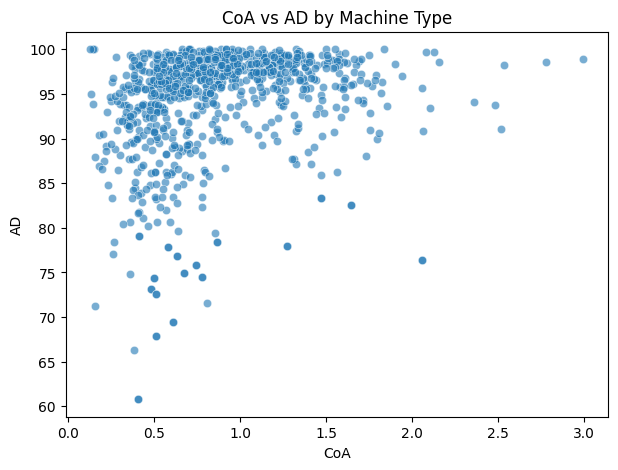

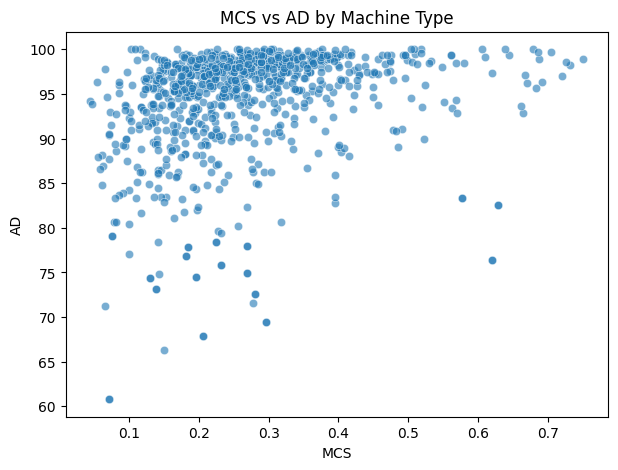

In [209]:
for f in features:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=df[df["MachineType"]=="TrueBeam"],  # filter for TrueBeam only
        x = f,
        y="AD",
        alpha=0.6
    )
    plt.title(f"{f} vs AD by Machine Type")
    plt.show()
   

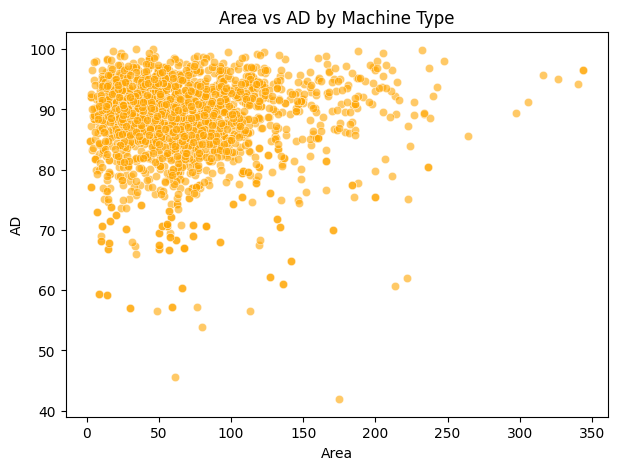

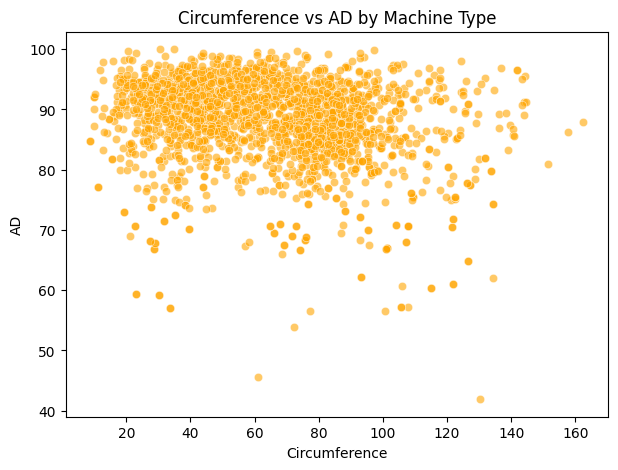

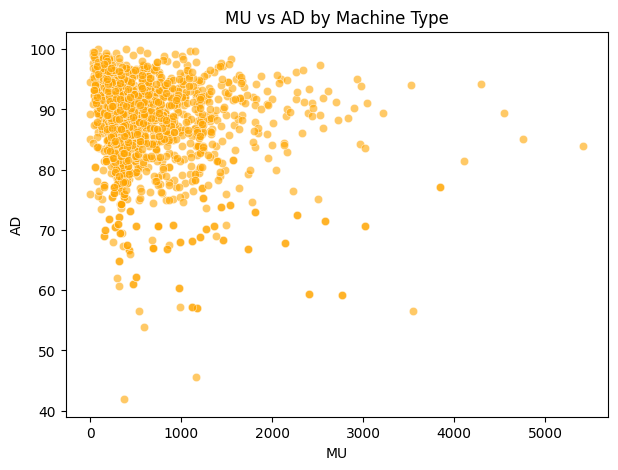

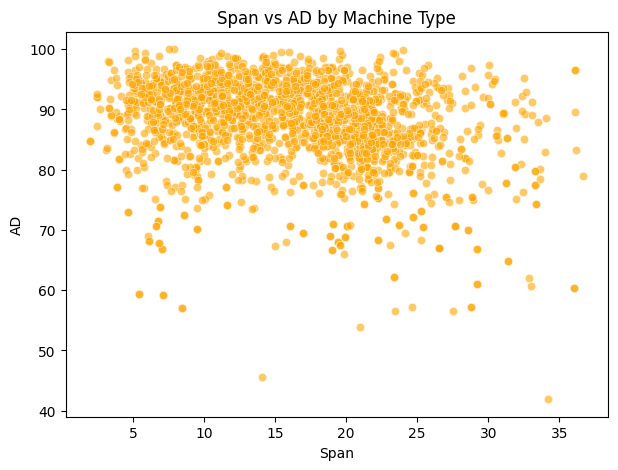

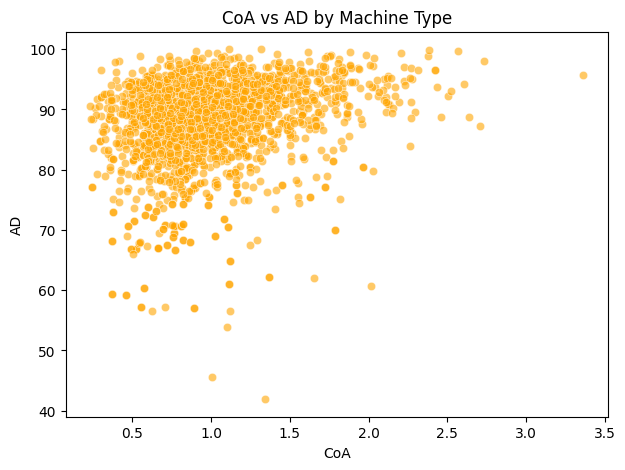

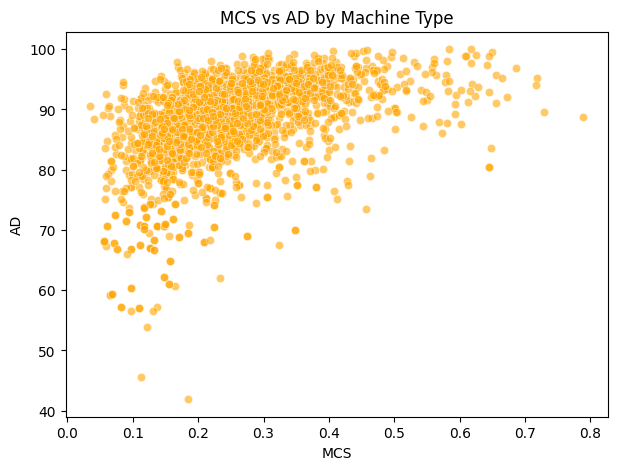

In [211]:
for f in features:
    plt.figure(figsize=(7,5))
    sns.scatterplot(
        data=df[df["MachineType"]=="Agility"],  # filter for TrueBeam only
        x = f,
        y="AD",
        alpha=0.6,
        color='orange'
    )
    plt.title(f"{f} vs AD by Machine Type")
    plt.show()
   

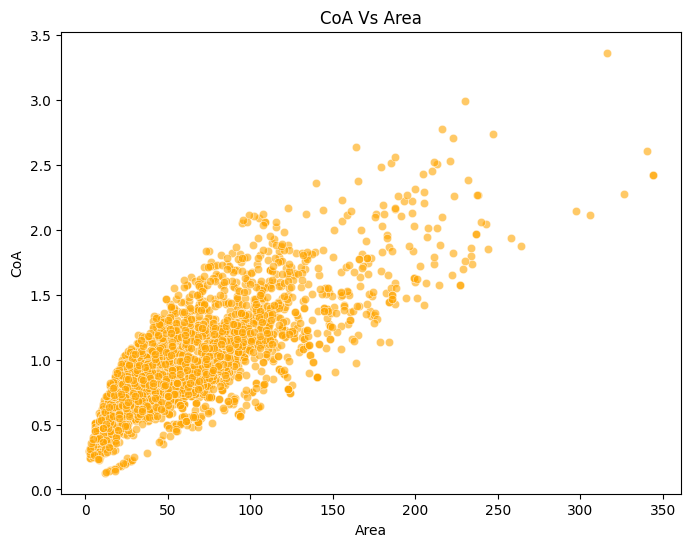

In [213]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
        data=df,  # filter for TrueBeam only
        x = "Area",
        y="CoA",
        alpha=0.6,
        color='orange'
    )
plt.title("CoA Vs Area")
plt.show()

<Axes: >

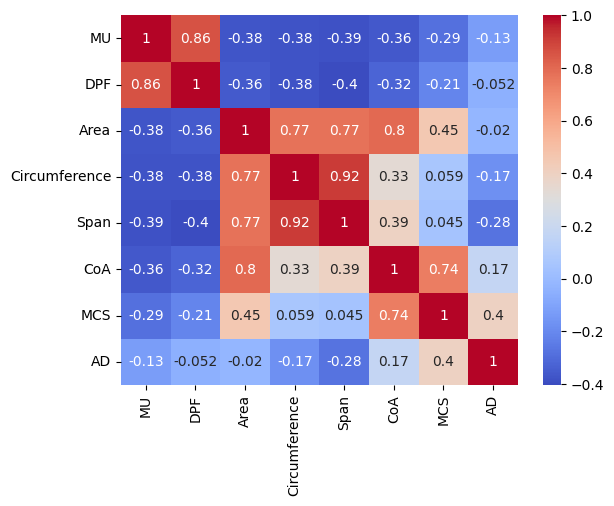

In [185]:

num_cols = ["MU", "DPF", "Area", "Circumference", "Span", "CoA", "MCS"]
import matplotlib.pyplot as plt
corr = df[num_cols + ["AD"]].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm")



In [186]:
import numpy as np
import pandas as pd
from typing import Iterable, Optional, Union, List, Dict
features = ['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS']
df_num = df[features]
tbl = df_num.describe().T
tbl = tbl.rename(columns={"25%":"q1", "50%":"median", "75%":"q3"})
tbl["iqr"] = tbl["q3"] - tbl["q1"]

In [187]:
if "AD" in df.columns:
    tbl["corr_with_AD"] = df_num.corrwith(df["AD"])


In [188]:
tbl = tbl[["count","mean","std","min","q1","median","q3","max","iqr"] + (["corr_with_AD"] if "corr_with_AD" in tbl.columns else [])]
tbl = tbl.round(4)

In [35]:
print(tbl)

                count      mean       std     min        q1    median  \
Area           2473.0   63.7666   47.3087  2.5991   26.0687   55.6872   
Circumference  2473.0   62.0123   31.3674  8.7941   36.4853   58.3381   
MU             2473.0  711.0729  871.7446  0.0000  249.1000  366.0000   
Span           2473.0   14.9037    6.9755  2.0000    9.0804   14.3072   
CoA            2473.0    0.9585    0.4199  0.1291    0.6564    0.8918   
MCS            2473.0    0.2558    0.1183  0.0441    0.1703    0.2346   

                     q3        max       iqr  corr_with_AD  
Area            87.5703   344.1594   61.5017       -0.0168  
Circumference   81.6198   168.2324   45.1344       -0.1751  
MU             846.8000  7930.0000  597.7000       -0.1351  
Span            19.8973    37.8046   10.8169       -0.2707  
CoA              1.1891     3.3653    0.5326        0.1724  
MCS              0.3172     0.7893    0.1469        0.3839  


In [97]:
def table_summary(df):
    features = ['Area', 'Circumference', 'MU', "Span" ,'CoA','MCS',"Mu_per_dpf"]
    df_num = df[features]
    tbl = df_num.describe().T
    tbl = tbl.rename(columns={"25%":"q1", "50%":"median", "75%":"q3"})
    tbl["iqr"] = tbl["q3"] - tbl["q1"]
    if "AD" in df.columns:
        tbl["corr_with_AD"] = df_num.corrwith(df["AD"])
    tbl = tbl[["count","mean","std","min","q1","median","q3","max","iqr"] + (["corr_with_AD"] if "corr_with_AD" in tbl.columns else [])]
    tbl = tbl.round(4)
    return tbl

    

In [189]:
table_summary(df[df["MachineType"]=="TrueBeam"])

,count,mean,std,min,q1,median,q3,max,iqr,corr_with_AD
Area,841.0,49.5146,40.7017,2.7337,17.7559,38.4589,71.3912,258.1212,53.6353,0.1260
Circumference,841.0,55.2473,36.5247,9.8470,27.8081,44.0130,71.9992,168.2324,44.1911,-0.0147
MU,841.0,989.3008,1256.5366,23.0000,239.0000,417.0000,1434.0000,7930.0000,1195.0000,-0.3730
Span,841.0,12.3149,6.3335,2.5977,7.5351,11.1307,16.3384,37.8046,8.8033,-0.0430
CoA,841.0,0.8669,0.4270,0.1291,0.5457,0.7917,1.1264,2.9950,0.5808,0.2511
MCS,841.0,0.2662,0.1251,0.0441,0.1797,0.2480,0.3253,0.7515,0.1456,0.2599
Mu_per_dpf,841.0,1.4837,0.7161,0.1278,1.0241,1.3556,1.8262,6.0942,0.8021,-0.3039


In [214]:
table_summary(df[df["MachineType"]!="TrueBeam"])
df[df["MU"]==0]

,QADate,Unit,Energy,MU,DPF,ADPass,RDPass,AD,RD,D4DD,D4DTA,D4Gamma,Area,Circumference,MCS,Span,CoA,MachineType,Mu_per_dpf
770,2024-03-14,NA10,6.0X,0.0,1000,80,95,85.1,94.1,0.0,0.0,0.0,5.535472,16.833889,0.073712,4.548545,0.328829,Agility,0.0
1418,2024-02-05,EA08,6.0X,0.0,1000,75,90,89.3,99.6,0.0,0.0,0.0,38.735446,38.282574,0.298389,9.822060,1.011830,Agility,0.0
1419,2024-02-05,EA08,6.0X,0.0,1000,75,90,94.6,99.7,0.0,0.0,0.0,41.601188,42.295248,0.288588,10.759077,0.983590,Agility,0.0
2263,2024-01-31,NA12,6X,0.0,600,76,95,76.0,96.9,0.0,0.0,0.0,63.284833,76.867556,0.116005,22.937868,0.823297,Agility,0.0


## Checking how many fields have full arcs :

In [ ]:
import os
import pandas as pd

def build_field_attributes(dates_path, full_arc_n=180, save_csv=None):
    """
    Scan all subfolders in `dates_path`, read fields, and return a DataFrame
    with one row per field and handy attributes.

    Columns returned:
      FieldID, MachineType, Area, Circumference, MCS, Span, CoA,
      NControlPoints, IsFullArc, DateFolder
    """
    from field import Field  
    broken = []
    rows = []
    for date in os.listdir(dates_path):
        folder = os.path.join(dates_path, date)
        if not os.path.isdir(folder):
            continue

        for fname in os.listdir(folder):
            if "MetaData" in fname or fname.endswith(".txt"):
                continue
            path = os.path.join(folder, fname)
            try:
                f = Field(path)
            except Exception as e:
                broken.append(f.field_ID)

                continue

            if getattr(f, "ncontrolpoints", None) is not None:
                ncp = int(f.ncontrolpoints)
            elif getattr(f, "cp", None) is not None:
                ncp = len(f.cp)
            elif getattr(f, "mq_control_points", None) is not None:
                ncp = len(f.mq_control_points)
            else:
                ncp = None

          
            area = f.gantry_total_areas.mean()
            circ = f.aperture_circumference.mean()
            span = max(f.span)
            coa  = area / circ if (circ not in (0, None)) else None

            rows.append({
                "FieldID":        f.field_ID,
                "MachineType":    f.machine_type,
                "Area":           area,
                "Circumference":  circ,
                "MCS":            f.MCS_arc,
                "Span":           span,
                "CoA":            coa,
                "NControlPoints": ncp,
                "IsFullArc":      int(ncp == full_arc_n) if ncp is not None else None,
                "DateFolder":     date,
            })

    df = pd.DataFrame(rows).drop_duplicates(subset=["FieldID"]).set_index("FieldID")

    if save_csv:
        df.to_csv(save_csv, index=True)
        print(f"Saved {len(df)} fields to: {save_csv}")

    return df


In [197]:
dates = "/Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset"
master = build_field_attributes(dates, full_arc_n=180, save_csv="field_attributes.csv")

# quick sanity checks
#print(master.head())
print("Full-arc fields:", master["IsFullArc"].sum())


Saved 2712 fields to: field_attributes.csv
Full-arc fields: 2040


In [218]:
print(master.sort_values("NControlPoints", ascending=True).head(10))

        MachineType        Area  Circumference       MCS       Span       CoA  \
FieldID                                                                         
2413591    TrueBeam  107.497857      50.574286  0.704924  11.642752  2.125544   
2426690    TrueBeam   88.929286      48.748571  0.691817  11.695700  1.824244   
2406966     Agility   61.818437      47.228750  0.426962  13.646034  1.308915   
2402306    TrueBeam   95.386875      45.860000  0.686465   9.613188  2.079958   
2416350     Agility   14.697500      23.378750  0.476859   6.605999  0.628669   
2404746     Agility   30.091563      41.895000  0.209124   9.779353  0.718261   
2402726    TrueBeam   53.935938      34.750000  0.638495   8.234511  1.552113   
2434160     Agility   23.423125      31.992500  0.610242   5.146526  0.732144   
2407213    TrueBeam    8.462813      14.150000  0.350197   3.255281  0.598079   
2408141     Agility   17.937500      20.733750  0.484176   5.988358  0.865135   

         NControlPoints  Is

In [199]:
print(master["IsFullArc"].value_counts())

IsFullArc
1    2040
0     672
Name: count, dtype: int64


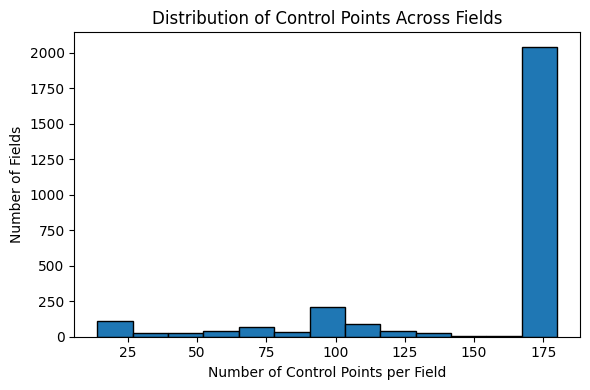

In [200]:
import matplotlib.pyplot as plt





plt.figure(figsize=(6,4))
plt.hist(master["NControlPoints"], bins='auto', edgecolor='black')
plt.xlabel("Number of Control Points per Field")
plt.ylabel("Number of Fields")
plt.title("Distribution of Control Points Across Fields")
plt.tight_layout()
plt.show()


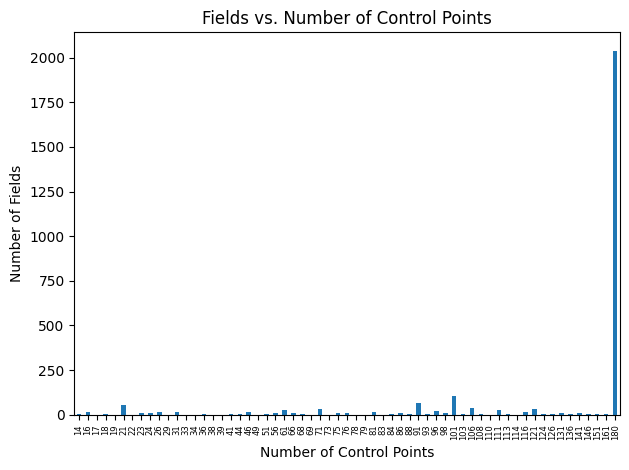

In [201]:
master["NControlPoints"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Number of Control Points")
plt.ylabel("Number of Fields")
plt.title("Fields vs. Number of Control Points")

# Rotate x-axis labels for readability
plt.xticks(rotation=90, fontsize=6)

plt.tight_layout()
plt.show()


In [202]:

print(master["NControlPoints"].value_counts().sort_index())


NControlPoints
14        2
16       13
17        1
18        6
19        1
21       53
22        1
23       12
24        7
26       15
29        1
31       15
33        1
34        1
36        4
38        1
39        1
41        3
44        2
46       13
49        1
51        6
56       11
61       29
66       12
68        3
69        1
71       30
73        1
75       10
76        9
78        1
79        1
81       13
83        1
84        3
86        9
88        2
91       63
93        2
96       21
98       12
101     105
103       5
106      35
108       2
110       1
111      29
113       6
114       1
116      18
121      33
124       2
126       6
131      10
136       5
141       9
146       3
151       2
161       6
180    2040
Name: count, dtype: int64


In [ ]:
#df["Mu_per_dpf"]= df["MU"] / df["DPF"]
#f.to_csv("updated_df.csv", index=False)
print(df.head())

            QADate  Unit   Energy      MU   DPF  ADPass  RDPass    AD     RD  \
FieldID                                                                        
2415563 2024-02-07  EV06     6.0X  1517.0   600      88      95  97.9  100.0   
2415391 2024-02-07  EV06     6.0X  1238.0   700      88      95  98.6  100.0   
2415601 2024-02-07  EV06   6.0FFF  1837.0  1000      76      95  86.3  100.0   
2415536 2024-02-07  EV06  10.0FFF  1052.0   600      76      95  96.8  100.0   
2415520 2024-02-07  EV06     6.0X   738.0   500      75      90  91.7   98.1   

         D4DD  ...  D4Gamma       Area  Circumference       MCS      Span  \
FieldID        ...                                                          
2415563   0.0  ...      0.0  25.371694      28.620556  0.317466  8.543715   
2415391   0.0  ...      0.0  16.666194      21.229556  0.317221  6.221047   
2415601   0.0  ...      0.0   6.697194      13.289778  0.293544  3.636971   
2415536   0.0  ...      0.0  30.969139      32.582778 

In [94]:
df = df[df["DPF"]!=0]

In [102]:
df.sort_values(by="FieldID", ascending=True)

,QADate,Unit,Energy,MU,DPF,ADPass,RDPass,AD,RD,D4DD,...,D4Gamma,Area,Circumference,MCS,Span,CoA,MachineType,PID,area_bin,Mu_per_dpf
FieldID,,,,,,,,,,,,,,,,,,,,,
2392807,2024-01-09,NA11,6X,403.3,220,83,95,77.8,99.4,84.2,...,93.7,117.226889,126.249556,0.199841,31.239853,0.928533,Agility,13.0,"(105.067, 122.145]",1.833182
2392807,2024-02-13,WA17,6X,403.3,220,83,95,77.8,99.4,84.2,...,93.7,117.226889,126.249556,0.199841,31.239853,0.928533,Agility,14.0,"(105.067, 122.145]",1.833182
2392808,2024-02-13,WA17,6X,444.2,220,83,95,90.9,99.1,67.6,...,83.0,185.699889,126.548667,0.308761,30.131577,1.467419,Agility,14.0,"(173.379, 190.457]",2.019091
2392808,2024-01-09,NA11,6X,444.2,220,83,95,90.9,99.1,67.6,...,83.0,185.699889,126.548667,0.308761,30.131577,1.467419,Agility,13.0,"(173.379, 190.457]",2.019091
2394763,2024-01-09,NA11,6X,245.0,200,75,90,96.5,99.6,78.7,...,84.4,344.159414,141.922342,0.466928,36.068692,2.424984,Agility,7.0,"(327.081, 344.159]",1.225000
2394763,2024-02-13,WA17,6X,245.0,200,75,90,96.5,99.6,78.7,...,84.4,344.159414,141.922342,0.466928,36.068692,2.424984,Agility,1.0,"(327.081, 344.159]",1.225000
2394764,2024-01-09,NA11,6X,201.6,200,75,90,71.8,97.1,48.6,...,57.7,131.995586,121.999459,0.161774,22.781860,1.081936,Agility,7.0,"(122.145, 139.223]",1.008000
2394764,2024-02-13,WA17,6X,201.6,200,75,90,71.8,97.1,48.6,...,57.7,131.995586,121.999459,0.161774,22.781860,1.081936,Agility,1.0,"(122.145, 139.223]",1.008000
2405129,2024-01-04,EA08,6X,341.1,200,83,95,81.8,98.1,84.9,...,95.5,104.592556,95.194889,0.287158,23.358217,1.098720,Agility,4.0,"(87.989, 105.067]",1.705500


In [ ]:
import pandas as pd

df = pd.read_csv("updated_df.csv")


Empty DataFrame
Columns: [QADate, Unit, Energy, MU, DPF, ADPass, RDPass, AD, RD, D4DD, D4DTA, D4Gamma, Area, Circumference, MCS, Span, CoA, MachineType, PID, area_bin, Mu_per_dpf]
Index: []

[0 rows x 21 columns]


In [138]:
sum = 0
for date in os.listdir(dates):
    folder = os.path.join(dates, date)
    
    if os.path.isdir(folder):
        n_files = len(os.listdir(folder))
        sum += n_files


        print(f"{date}: {n_files} files")
print(f"{sum}")


2023-12-8: 38 files
2024-02-07: 19 files
2024-01-18: 25 files
2024-01-11: 29 files
2023-12-14: 21 files
2024-02-09: 42 files
2023-12-13: 26 files
2024-01-16: 29 files
2024-01-29: 38 files
2024-01-17: 36 files
2023-12-12: 43 files
2023-12-15: 32 files
2024-01-10: 29 files
2024-02-01: 34 files
2024-01-26: 27 files
2024-01-19: 42 files
2024-02-06: 38 files
2024-04-18: 48 files
2024-03-08: 27 files
2024-03-01: 26 files
2024-04-16: 22 files
2024-04-29: 41 files
2024-04-11: 29 files
2024-03-06: 41 files
2024-03-07: 33 files
2024-04-17: 34 files
2024-04-26: 33 files
2024-04-19: 38 files
2024-04-04: 26 files
2024-03-13: 29 files
2024-03-14: 24 files
2024-04-03: 19 files
2024-03-22: 38 files
2024-03-25: 39 files
2024-04-02: 26 files
2024-03-15: 25 files
2024-03-12: 47 files
2024-04-05: 31 files
2024-01-03: 30 files
2024-02-23: 31 files
2024-01-04: 36 files
2024-02-15: 39 files
2024-02-12: 26 files
2024-02-13: 50 files
2024-02-14: 40 files
2024-01-05: 38 files
2024-02-22: 31 files
2024-01-02: 44

In [141]:
from sklearn.preprocessing import StandardScaler #statndardize features by removing the mean and scaling to unit variance
from sklearn.model_selection import train_test_split #split arrays or matrices into random train and test subsets
import sys # for manipulating the Python runtime environment
import os # for interacting with the operating system

# Get the current working directory (where the notebook is located)
current_dir = os.getcwd() # Get the current directory

# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, '..'))
# Ensure the parent directory is in sys.path so we can import modules from it
# Add the parent directory to sys.path
sys.path.insert(0, parent_dir)
from field import Field



from data_creator import load_2D
df = load_2D().dropna()

Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2415735.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2416143.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy-Quality-Assurance/notebooks/Dataset/2024-02-09/FieldID_2415736.json - Error: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 0)
Skipping broken file in load_2D: /Users/armin/Desktop/Banafshe/project/test/Radiotherapy

In [142]:
print(df.shape)

(2510, 19)


In [148]:

df['QADate'].value_counts()



QADate
02/16/2024    52
02/13/2024    48
04/18/2024    47
04/12/2024    47
03/11/2024    47
03/12/2024    46
04/08/2024    43
01/19/2024    41
01/08/2024    40
01/09/2024    40
04/29/2024    39
04/30/2024    39
02/09/2024    38
02/06/2024    37
03/19/2024    37
01/29/2024    37
03/20/2024    37
01/05/2024    37
02/15/2024    36
03/25/2024    36
01/12/2024    36
03/06/2024    36
02/14/2024    35
01/17/2024    35
04/19/2024    35
01/15/2024    34
02/27/2024    34
01/04/2024    34
04/23/2024    33
02/01/2024    33
03/22/2024    33
04/01/2024    33
04/17/2024    33
02/20/2024    32
01/31/2024    32
03/07/2024    32
03/26/2024    31
03/28/2024    31
04/09/2024    31
01/25/2024    31
02/26/2024    31
02/21/2024    31
04/26/2024    31
04/15/2024    30
04/05/2024    30
02/22/2024    30
02/29/2024    30
02/23/2024    30
02/05/2024    29
03/13/2024    28
01/30/2024    28
04/11/2024    28
01/10/2024    28
03/27/2024    28
01/03/2024    28
01/11/2024    28
03/04/2024    27
01/16/2024    27
02/28/2

In [150]:
df.shape

(2510, 19)

In [152]:
df_cropped = load_2D()

In [158]:
df_cropped.shape

(327, 18)

In [219]:
df_cropped.to_csv("cropped_df.csv", index=False)

In [156]:
df_updated = df.drop("PID", axis=1)

In [157]:
df_updated.shape

(2510, 18)

In [159]:
df_merge = pd.concat([df_updated, df_cropped], axis=0)

In [162]:
df_merge["QADate"].value_counts()

QADate
02/16/2024    52
02/13/2024    48
03/11/2024    47
04/12/2024    47
04/18/2024    47
03/12/2024    46
04/08/2024    43
12/12/2023    42
01/19/2024    41
01/09/2024    40
01/08/2024    40
04/29/2024    39
04/30/2024    39
11/06/2023    38
02/09/2024    38
01/05/2024    37
03/19/2024    37
12/08/2023    37
03/20/2024    37
02/06/2024    37
01/29/2024    37
03/06/2024    36
03/25/2024    36
02/15/2024    36
01/12/2024    36
02/14/2024    35
12/20/2023    35
01/17/2024    35
04/19/2024    35
02/27/2024    34
01/04/2024    34
01/15/2024    34
04/17/2024    33
04/01/2024    33
02/01/2024    33
03/22/2024    33
04/23/2024    33
01/31/2024    32
02/20/2024    32
03/07/2024    32
12/11/2023    32
01/25/2024    31
02/26/2024    31
02/21/2024    31
04/09/2024    31
03/28/2024    31
12/15/2023    31
03/26/2024    31
04/26/2024    31
02/29/2024    30
04/05/2024    30
02/23/2024    30
02/22/2024    30
04/15/2024    30
02/05/2024    29
01/03/2024    28
01/11/2024    28
01/30/2024    28
04/11/2

In [163]:
df_merge.shape

(2837, 18)

In [167]:
df_merge = df_merge[df_merge["AD"]!=0]

In [172]:
df =df_merge[df_merge["DPF"]!=0]

In [ ]:
df["Mu_per_dpf"]= df["MU"] / df["DPF"]
#df.to_csv("updated_df.csv", index=False)

In [203]:
df_cropped = df_cropped[df_cropped["AD"]!=0]
df_cropped[df_cropped["DPF"]!=0]
df_cropped.to_csv("cropped_df.csv", index=False)
